<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/catdog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import warnings

warnings.filterwarnings("ignore")
torch.__version__

'2.11.0+cpu'

In [3]:
import kagglehub

path = kagglehub.dataset_download("muniryadi/cat-vs-rabbit")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-vs-rabbit' dataset.
Path to dataset files: /kaggle/input/cat-vs-rabbit


In [4]:
from pathlib import Path
import os

data_path = Path("/kaggle/input/cat-vs-rabbit")
data_path

PosixPath('/kaggle/input/cat-vs-rabbit')

In [8]:
for dirpath, dirnames, filenames in os.walk(data_path):
  print(f"dirpath: {dirpath}, dirnames: {len(dirnames)}, filenames: {len(filenames)}")

dirpath: /kaggle/input/cat-vs-rabbit, dirnames: 3, filenames: 0
dirpath: /kaggle/input/cat-vs-rabbit/test-images, dirnames: 2, filenames: 0
dirpath: /kaggle/input/cat-vs-rabbit/test-images/rabbit, dirnames: 0, filenames: 5
dirpath: /kaggle/input/cat-vs-rabbit/test-images/cat, dirnames: 0, filenames: 10
dirpath: /kaggle/input/cat-vs-rabbit/train-cat-rabbit, dirnames: 2, filenames: 0
dirpath: /kaggle/input/cat-vs-rabbit/train-cat-rabbit/rabbit, dirnames: 0, filenames: 800
dirpath: /kaggle/input/cat-vs-rabbit/train-cat-rabbit/cat, dirnames: 0, filenames: 800
dirpath: /kaggle/input/cat-vs-rabbit/val-cat-rabbit, dirnames: 2, filenames: 0
dirpath: /kaggle/input/cat-vs-rabbit/val-cat-rabbit/rabbit, dirnames: 0, filenames: 207
dirpath: /kaggle/input/cat-vs-rabbit/val-cat-rabbit/cat, dirnames: 0, filenames: 207


In [18]:
all_images = list(data_path.glob("*/*/*.jpg"))
len(all_images)

2024

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import random

Random_Img_Paths = random.sample(all_images, k=3)
Random_Img_Paths

[PosixPath('/kaggle/input/cat-vs-rabbit/train-cat-rabbit/rabbit/rabbit.674.jpg'),
 PosixPath('/kaggle/input/cat-vs-rabbit/val-cat-rabbit/rabbit/rabbit.129.jpg'),
 PosixPath('/kaggle/input/cat-vs-rabbit/val-cat-rabbit/cat/cat.167.jpg')]

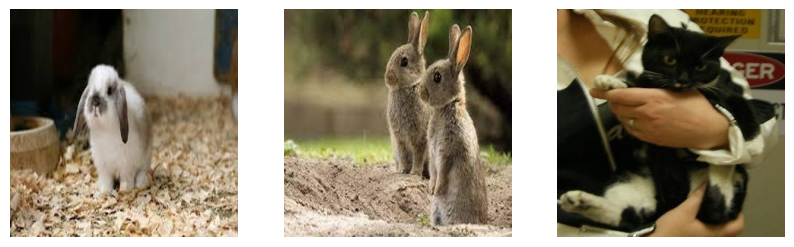

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(10,5))
for i, r_path in enumerate(Random_Img_Paths):
  img = Image.open(r_path)
  ax[i].imshow(img)
  ax[i].axis("off")

In [25]:
from torchvision import transforms

img_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.4)
])

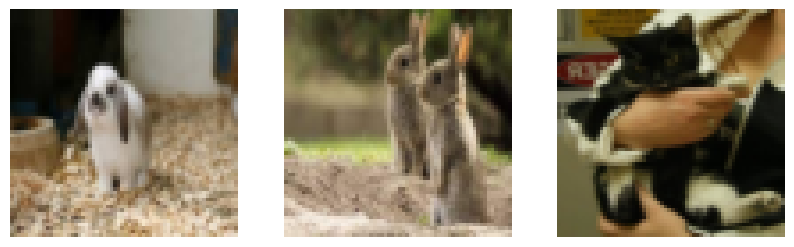

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(10,5))
for i, r_path in enumerate(Random_Img_Paths):
  img = Image.open(r_path)
  img_trans = img_transforms(img)
  ax[i].imshow(img_trans)
  ax[i].axis("off")

In [28]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_transforms

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.4)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [29]:
test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transforms

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [30]:
from torchvision.datasets import ImageFolder

train_imagefolder = ImageFolder("/kaggle/input/cat-vs-rabbit/train-cat-rabbit", transform=train_transforms)
test_imagefolder = ImageFolder("/kaggle/input/cat-vs-rabbit/test-images", transform=test_transforms)

In [32]:
train_imagefolder, test_imagefolder

(Dataset ImageFolder
     Number of datapoints: 1600
     Root location: /kaggle/input/cat-vs-rabbit/train-cat-rabbit
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.4)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 15
     Root location: /kaggle/input/cat-vs-rabbit/test-images
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [33]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_imagefolder, batch_size=32, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_imagefolder, batch_size=32, shuffle=False, num_workers=2)

In [37]:
IMAGES, LABELS = next(iter(train_dataloader))
LABELS

tensor([1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 1])

In [56]:
from torch import nn

class TinnyVggModel(nn.Module):
  def __init__(self, input_s, output_s, hidden_u):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_s, out_channels=hidden_u, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_u, out_channels=hidden_u, kernel_size=3, stride=1, padding=0),
        nn.MaxPool2d(kernel_size=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_u, out_channels=hidden_u, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_u, out_channels=hidden_u, kernel_size=3, stride=1, padding=0),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_u*13*13, out_features=output_s)
    )
  def forward(self, x):
    x = self.block_1(x)
    #print(f"shape --> {x.shape}")
    x = self.block_2(x)
    #print(f"shape --> {x.shape}")
    x = self.classifier(x)
    return x


In [62]:
input_s = 3
output_s = 1
hidden_u = 10

In [63]:
model = TinnyVggModel(input_s, output_s, hidden_u)
model

TinnyVggModel(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=1, bias=True)
  )
)

In [64]:
test_img, test_label = IMAGES[0], LABELS[0]

In [65]:
test_img[:1], test_label

(tensor([[[-1.2274, -1.1932, -1.1418,  ..., -1.0390, -1.0390, -1.0562],
          [-1.2617, -1.2103, -1.1589,  ..., -1.0048, -1.0219, -1.0390],
          [-1.2445, -1.2103, -1.1932,  ..., -1.0048, -1.0219, -1.0390],
          ...,
          [-1.0219, -0.7650, -1.1418,  ..., -1.0733, -1.0562, -1.3987],
          [-1.0733, -0.7993, -1.0219,  ..., -1.2788, -1.2103, -1.3473],
          [-1.0562, -1.0733, -1.1932,  ..., -1.6042, -1.4158, -1.1247]]]),
 tensor(1))

In [66]:
test_img.shape

torch.Size([3, 64, 64])

In [53]:
k = test_img.unsqueeze(dim=0)
k.shape

torch.Size([1, 3, 64, 64])

In [67]:
with torch.inference_mode():
  pred = model(k)

pred

tensor([[-0.0129]])

In [68]:
torch.round(torch.sigmoid(pred))

tensor([[0.]])

In [84]:
def accuracy_fn(y_true, y_pred):
    correct = (y_true == y_pred).sum().item()
    total = len(y_true)
    accuracy = (correct / total) * 100
    return accuracy

accuracy_fn(torch.Tensor([1,2,3]), torch.Tensor([1,2,3]))

100.0

In [69]:
from torch.nn import BCEWithLogitsLoss
from torch.optim import SGD

criterion = BCEWithLogitsLoss()
optimizer = SGD(params=model.parameters(), lr=0.01)

In [70]:
TRAIN_LOSS = []
TEST_LOSS = []
EPOCH = []

In [71]:
from tqdm import tqdm

In [86]:
for epoch in tqdm(range(20)):
  model.train()
  train_loss = 0
  for image, label in train_dataloader:
    logits = model(image)
    pred = torch.round(torch.sigmoid(logits))
    loss = criterion(logits, label.unsqueeze(1).float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  avg_loss = train_loss/len(train_dataloader)

  model.eval()
  with torch.inference_mode():
    test_loss = 0
    for test_img, test_label in test_dataloader:
      te_logits = model(test_img)
      te_pred = torch.round(torch.sigmoid(te_logits))
      te_loss = criterion(te_logits, test_label.unsqueeze(1).float())

      test_loss += te_loss.item()

    avg_test_loss = test_loss/len(test_dataloader)

  if epoch % 2 == 0:
    print(f"\n__Epoch__: {epoch}")
    print(f"\nTraining Loss: {avg_loss:.5f}")
    print(f"\nTesting Loss: {avg_test_loss:.5f}")
    EPOCH.append(epoch)
    TRAIN_LOSS.append(avg_loss)
    TEST_LOSS.append(avg_test_loss)

  5%|▌         | 1/20 [00:08<02:44,  8.67s/it]


__Epoch__: 0

Training Loss: 0.41123

Testing Loss: 0.41550


 15%|█▌        | 3/20 [00:24<02:21,  8.34s/it]


__Epoch__: 2

Training Loss: 0.40804

Testing Loss: 0.40025


 25%|██▌       | 5/20 [00:43<02:19,  9.32s/it]

...

 85%|████████▌ | 17/20 [02:23<00:24,  8.21s/it]


__Epoch__: 16

Training Loss: 0.37185

Testing Loss: 0.42596


 95%|█████████▌| 19/20 [02:40<00:08,  8.46s/it]


__Epoch__: 18

Training Loss: 0.37224

Testing Loss: 0.37481


100%|██████████| 20/20 [02:47<00:00,  8.39s/it]


In [87]:
EPOCH

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

[]

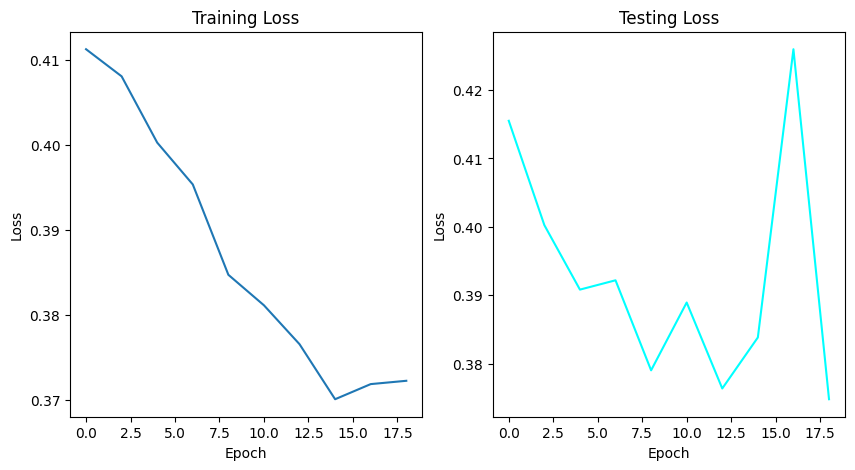

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].plot(EPOCH, TRAIN_LOSS)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(EPOCH, TEST_LOSS, c="cyan")
ax[1].set_title("Testing Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.plot()